In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pandas as pd
import pickle

In [13]:
umap_df = pd.read_pickle("/Users/suthardr/Desktop/umap_test.pkl")

In [14]:
umap_df

,x,y,waveform,cluster_id,cluster_color
250,11.800549,7.929263,"[0.02285566904042985, 0.14134875312739031, 0.2...",0,"[0.18995, 0.07176, 0.23217, 1.0]"
215,11.220973,8.712428,"[-0.12868336753753828, -0.2009273190397869, -0...",0,"[0.18995, 0.07176, 0.23217, 1.0]"
171,11.762025,8.297231,"[-0.039271263759884656, -0.1217643146680771, -...",0,"[0.18995, 0.07176, 0.23217, 1.0]"
174,10.600965,7.658712,"[0.0938943302952543, 0.3236298312898768, 0.411...",0,"[0.18995, 0.07176, 0.23217, 1.0]"
213,11.992494,7.406099,"[-0.1015766062295112, -0.0925603877103961, -0....",0,"[0.18995, 0.07176, 0.23217, 1.0]"
...,...,...,...,...,...
208,12.820193,7.544336,"[-0.25914412825963334, -0.2911690336530747, -0...",3,"[0.4796, 0.01583, 0.01055, 1.0]"
119,12.404117,11.639379,"[-0.013815990733480797, -0.05452932479991414, ...",3,"[0.4796, 0.01583, 0.01055, 1.0]"
205,13.123128,7.546952,"[-0.3938483111197135, -0.38111233880616524, -0...",3,"[0.4796, 0.01583, 0.01055, 1.0]"
221,13.249976,9.132865,"[-0.1979199610877514, -0.1498834662395898, -0....",3,"[0.4796, 0.01583, 0.01055, 1.0]"


In [15]:
#Sort your umap_df by cluster_id for plotting
umap_df = umap_df.sort_values(['cluster_id'])

#Make into a cute little numpy array and save as result
numpy_list = [array for array in umap_df['waveform']]
result = np.vstack(numpy_list)

In [16]:
result

array([[ 0.02285567,  0.14134875,  0.28193304, ...,  0.41170166,
         0.31959208,  0.1981297 ],
       [ 0.34095444,  0.28863614,  0.27490257, ...,  0.26012089,
         0.26035798,  0.31117682],
       [ 0.08265113,  0.04968796, -0.00326085, ..., -0.14314185,
        -0.15247782, -0.15679638],
       ...,
       [ 0.44431728,  0.53096682,  0.46587041, ..., -0.50568459,
        -0.41586712, -0.34940844],
       [ 0.34940992,  0.43172553,  0.3917324 , ..., -0.06924601,
        -0.03952667, -0.03735681],
       [ 0.07769285,  0.09382047,  0.09677766, ..., -0.15797002,
        -0.12610143, -0.12225188]])

Text(52.722222222222214, 0.5, 'Cell #')

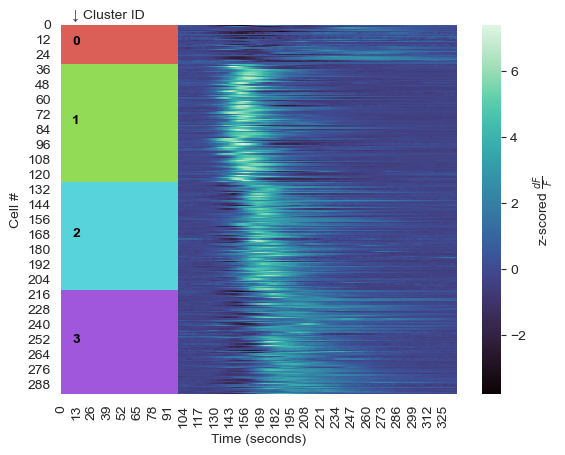

In [17]:
fig, ax = plt.subplots()

Ks=4 #What number of clusters are you plotting?
labels=umap_df['cluster_id']
cmap = sns.color_palette('hls', 4) #Change here the number of colors needed (# clusters)

# -> Cosmetic code to create a Rectangle patches to label specific K-cluster
Koffset = 0

sns.heatmap(result, cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"},cmap='mako',ax=ax)
for Ki in range(Ks):
    Nk = np.size(np.where(labels == Ki))
    # 40 is width of the rectangle
    rect = mpl.patches.Rectangle((0, Koffset), 100, Nk, linewidth=1, edgecolor='none', facecolor=cmap[Ki])
    ax.text(10, Koffset + Nk/2, Ki ,color='k', weight='bold')
    # Add the patch to the plot
    ax.add_patch(rect)
    Koffset += Nk
ax.text(10,-5,'↓ Cluster ID',fontsize=10)
# <- end of cosmetic code
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
# ax.set_xticks(np.linspace(0, result.shape[1], 12),
# labels=np.linspace(0, 330, 12, dtype=np.int))
# ax.set_yticks(np.linspace(0, result.shape[0], 10),
# labels=np.linspace(0, 250, 10, dtype=np.int))

In [18]:
#Do you want to look at a specific cluster? Look no further...
cluster1 = umap_df[umap_df['cluster_id']== 1]
numpy_list = [array for array in cluster1['waveform']]
cluster1 = np.vstack(numpy_list)
cluster1

array([[-0.28868925, -0.30298781, -0.32559253, ..., -0.30835199,
        -0.38131613, -0.37087723],
       [ 0.46494628,  0.34695633,  0.2211616 , ..., -0.08258402,
        -0.11615025, -0.00664665],
       [-0.55030824, -0.53709999, -0.51870651, ..., -0.27760984,
        -0.2680574 , -0.27352815],
       ...,
       [-0.03517933, -0.03738804, -0.04965054, ...,  0.03834464,
         0.00439346,  0.03508992],
       [-0.02732438,  0.02198464, -0.0172015 , ..., -0.25141207,
        -0.3003366 , -0.3396271 ],
       [ 0.00481946, -0.10008839, -0.03879536, ..., -0.2139704 ,
        -0.32045452, -0.29862304]])

In [ ]:
#Save that cluster numpy array for future use
np.save('/Users/suthardr/Desktop/cluster1_cxta_fc_shock.npy', cluster1)

Text(52.722222222222214, 0.5, 'Cell #')

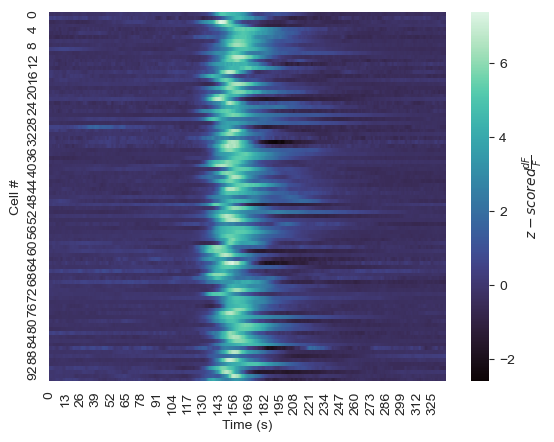

In [19]:
# Want to plot a heatmap for a specific cluster?

# Major ticks every 20, minor ticks every 5
fig, ax = plt.subplots()
sns.heatmap(cluster1, cbar=True, cbar_kws={"label": r"$z-scored \frac{dF}{F}$"}, cmap='mako', ax=ax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell #')
# ax.set_xticks(np.linspace(0, cluster0.shape[1], 12),
# labels=np.linspace(0, 330, 12, dtype=np.int))
# ax.set_yticks(np.linspace(0, cluster0.shape[0], 10),
# labels=np.linspace(0, 32, 10, dtype=np.int))

#Save that heatmap as a png because svg will blow up your laptop
#fig.savefig('/Users/suthardr/Desktop/recall_cxtb_heatmap_clusterzoom.png')


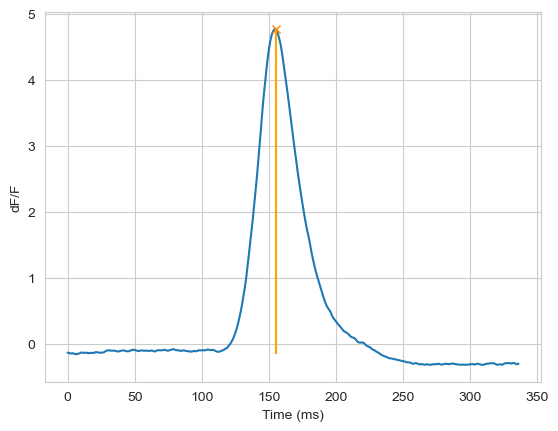

In [20]:
#Want to see what your average cluster plot looks like and find events?
avg = np.average(cluster1, axis=0)
peaks, properties = scipy.signal.find_peaks(avg, height=np.std(avg), distance=20, width=15, rel_height=0.5) #height =1 std, distance = 10Hz signal is 100ms/index, so 20 is 2 seconds,
    #width = 140ms decay time for GCaMP so 1.4, rel_height = 0.5 or FWHM
prominences = scipy.signal.peak_prominences(avg, peaks)[0]
height = avg[peaks]-prominences
properties #show the dictionary with the peak properties

    #
plt.figure()
plt.plot(avg)
plt.plot(peaks, avg[peaks], 'x')
plt.ylabel('dF/F')
plt.xlabel('Time (ms)')
plt.vlines(x=peaks, ymin=height, ymax=avg[peaks], color='orange')